In [1]:
!pip install Keras
!pip install vit-keras
!pip install tensorflow-addons
!pip install opendatasets
!pip install tensorflow-hub

import opendatasets as od
import pandas

import os

import keras.preprocessing
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras

from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from keras import layers
from keras import regularizers, activations
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.callbacks import ModelCheckpoint
from keras.layers import Dense, Dropout, Flatten, Activation, Concatenate, Lambda #....
from keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization, ZeroPadding2D #....
from keras.models import Model
from keras.optimizers import Adam
from keras.applications import ResNet50V2
from keras.preprocessing.image import ImageDataGenerator
from vit_keras import vit, utils


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 5.8 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [2]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# prompt: !unzip "/content/drive/MyDrive/MangoLeafBD Dataset.zip" and save it in Data folder

!unzip "/content/drive/MyDrive/Coconut Tree Disease Dataset.zip" -d "/content/Data2"


Streaming output truncated to the last 5000 lines.
  inflating: /content/Data2/Coconut Tree Disease Dataset/Bud Rot/BudRot288.jpg  
  inflating: /content/Data2/Coconut Tree Disease Dataset/Bud Rot/BudRot289.jpg  
  inflating: /content/Data2/Coconut Tree Disease Dataset/Bud Rot/BudRot290.jpg  
  inflating: /content/Data2/Coconut Tree Disease Dataset/Bud Rot/BudRot291.jpg  
  inflating: /content/Data2/Coconut Tree Disease Dataset/Bud Rot/BudRot292.jpg  
  inflating: /content/Data2/Coconut Tree Disease Dataset/Bud Rot/BudRot293.jpg  
  inflating: /content/Data2/Coconut Tree Disease Dataset/Bud Rot/BudRot294.jpg  
  inflating: /content/Data2/Coconut Tree Disease Dataset/Bud Rot/BudRot295.jpg  
  inflating: /content/Data2/Coconut Tree Disease Dataset/Bud Rot/BudRot296.jpg  
  inflating: /content/Data2/Coconut Tree Disease Dataset/Bud Rot/BudRot297.jpg  
  inflating: /content/Data2/Coconut Tree Disease Dataset/Bud Rot/BudRot298.jpg  
  inflating: /content/Data2/Coconut Tree Disease Dataset/B

In [4]:
import shutil
import os

# Define source and target directories
source_dir = '/content/Data2/Coconut Tree Disease Dataset/Bud Root Dropping'
target_dir = '/content/d1'

# Create the target directory if it doesn't exist
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# Move the entire folder with all its contents
shutil.move(source_dir, target_dir)


'/content/d1/Bud Root Dropping'

In [5]:
import shutil
import os

# Define source and target directories
source_dir = '/content/Data2/Coconut Tree Disease Dataset/Bud Rot'
target_dir = '/content/d1'

# Create the target directory if it doesn't exist
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# Move the entire folder with all its contents
shutil.move(source_dir, target_dir)


'/content/d1/Bud Rot'

In [6]:
import shutil
import os

# Define source and target directories
source_dir = '/content/Data2/Coconut Tree Disease Dataset/Gray Leaf Spot'
target_dir = '/content/d1'

# Create the target directory if it doesn't exist
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# Move the entire folder with all its contents
shutil.move(source_dir, target_dir)


'/content/d1/Gray Leaf Spot'

In [7]:
import shutil
import os

# Define source and target directories
source_dir = '/content/Data2/Coconut Tree Disease Dataset/Leaf Rot'
target_dir = '/content/d1'

# Create the target directory if it doesn't exist
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# Move the entire folder with all its contents
shutil.move(source_dir, target_dir)


'/content/d1/Leaf Rot'

In [8]:
import shutil
import os

# Define source and target directories
source_dir = '/content/Data2/Coconut Tree Disease Dataset/Stem Bleeding'
target_dir = '/content/d1'

# Create the target directory if it doesn't exist
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# Move the entire folder with all its contents
shutil.move(source_dir, target_dir)


'/content/d1/Stem Bleeding'

In [9]:

base_dir = '/content/d1'

In [10]:
import os

def get_folder_names(directory_path):
    # Initialize an empty list to store folder names
    folder_names = []

    # Iterate over items in the specified directory
    for item in os.listdir(directory_path):
        item_path = os.path.join(directory_path, item)

        # Check if the item is a directory
        if os.path.isdir(item_path):
          if item != '.ipynb_checkpoints':
            folder_names.append(item)

    return folder_names

# Specify the directory path for which you want to fetch folder names
directory_path = base_dir

# Call the function to get folder names in the specified directory
folders = get_folder_names(directory_path)

# Print the list of folder names
print("Folder Names:", folders)


Folder Names: ['Gray Leaf Spot', 'Bud Root Dropping', 'Stem Bleeding', 'Leaf Rot', 'Bud Rot']


In [11]:
# prompt: count the number of images from every subfolders

import os

# Get the base directory


# Get the list of subfolders
subfolders = os.listdir(base_dir)

# Initialize a dictionary to store the image counts
image_counts = {}

# Iterate through each subfolder
for subfolder in subfolders:
    # Get the path of the subfolder
    subfolder_path = os.path.join(base_dir, subfolder)

    # Check if the subfolder is a directory
    if os.path.isdir(subfolder_path):
        # Initialize the image count for the subfolder
        image_counts[subfolder] = 0

        # Get the list of files in the subfolder
        files = os.listdir(subfolder_path)

        # Iterate through each file in the subfolder
        for file in files:
            # Check if the file is an image
            if file.endswith(".jpg") or file.endswith(".png") or file.endswith(".jpeg"):
                # Increment the image count for the subfolder
                image_counts[subfolder] += 1

# Print the image counts for each subfolder
for subfolder, count in image_counts.items():
    print(f"Subfolder: {subfolder}, Image Count: {count}")


Subfolder: Gray Leaf Spot, Image Count: 2135
Subfolder: Bud Root Dropping, Image Count: 514
Subfolder: Stem Bleeding, Image Count: 1006
Subfolder: Leaf Rot, Image Count: 1673
Subfolder: Bud Rot, Image Count: 470


In [12]:
from PIL import Image
import os

def resize_images(input_folder, output_folder, target_size=(224, 224)):
    # Create the output folder if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Loop through all subfolders in the input folder
    for subfolder in os.listdir(input_folder):
        subfolder_path = os.path.join(input_folder, subfolder)
        if os.path.isdir(subfolder_path):  # Check if it's a directory
            output_subfolder = os.path.join(output_folder, subfolder)
            if not os.path.exists(output_subfolder):
                os.makedirs(output_subfolder)
            # Loop through all files in the subfolder
            for filename in os.listdir(subfolder_path):
                # Check if the file is an image
                if filename.endswith(('.png', '.jpg', '.jpeg', '.gif')):
                    # Open the image file
                    with Image.open(os.path.join(subfolder_path, filename)) as img:
                        # Resize the image
                        resized_img = img.resize(target_size)
                        # Save the resized image to the output folder
                        resized_img.save(os.path.join(output_subfolder, filename))

# Specify the input and output folders
input_folder = base_dir
output_folder = '/content/r'

# Call the function to resize images
resize_images(input_folder, output_folder)

In [13]:
base_dir = '/content/r'

In [14]:
import os
import cv2
from tqdm import tqdm

def invert_colors(image):
    inverted_image = cv2.bitwise_not(image)
    return inverted_image

def invert_colors_in_subfolders(root_directory, output_directory):
    # Iterate through subfolders
    for subfolder in os.listdir(root_directory):
        subfolder_path = os.path.join(root_directory, subfolder)

        # Check if it's a directory
        if os.path.isdir(subfolder_path):
            # Define source and output directories for the current subfolder
            source_directory = subfolder_path
            output_subfolder = os.path.join(output_directory, subfolder)

            # Create output directory if it doesn't exist
            if not os.path.exists(output_subfolder):
                os.makedirs(output_subfolder)

            # Process images in the current subfolder
            image_files = [f for f in os.listdir(source_directory) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))]
            for file_name in tqdm(image_files, desc="Processing " + subfolder):
                # Construct the input and output paths
                input_image_path = os.path.join(source_directory, file_name)
                output_image_path = os.path.join(output_subfolder, file_name)

                # Read the image
                image = cv2.imread(input_image_path)

                # Check if the image is loaded successfully
                if image is not None:
                    # Perform color inversion
                    inverted_image = invert_colors(image)

                    # Save the inverted image
                    cv2.imwrite(output_image_path, inverted_image)
                else:
                    print("Error: Could not open or find the image:", input_image_path)

# Example usage
root_directory = base_dir
output_directory = '/content/i1'  # Provide the path to your output directory
invert_colors_in_subfolders(root_directory, output_directory)


Processing Bud Rot: 100%|██████████| 470/470 [00:01<00:00, 263.53it/s]


In [15]:
base_dir = '/content/i1'

In [16]:
import numpy as np
import sys

# Monkey-patch numpy to use np.bool_
sys.modules['numpy'].bool = np.bool_

import os
import random
from tqdm import tqdm
from PIL import Image
import imgaug.augmenters as iaa

def augment_image(image, augmenter):
    image_np = np.array(image)
    augmented_image_np = augmenter(image=image_np)
    augmented_image = Image.fromarray(augmented_image_np)
    return augmented_image

def augment_images(source_directory, output_directory, target_count):
    # Define the augmentation pipeline using imgaug
    augmenter = iaa.Sequential([
        iaa.SomeOf((1, 4), [
            iaa.Fliplr(0.5),  # horizontal flips
            iaa.Affine(rotate=(-10, 10)),  # rotations
            iaa.Affine(scale=(0.8, 1.2)),  # zoom
            iaa.Affine(translate_percent={"x": (-0.2, 0.2), "y": (-0.2, 0.2)}),  # translations
            iaa.AdditiveGaussianNoise(scale=(10, 20)),  # Gaussian noise
            iaa.Multiply((0.8, 1.2)),  # brightness
            iaa.LinearContrast((0.8, 1.2))  # contrast
        ])
    ])

    # Ensure the destination directory exists; create it if necessary
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)

    # Get the list of files in the source directory
    image_files = [f for f in os.listdir(source_directory) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))]

    # Calculate the number of additional images needed
    existing_images = len(image_files)
    images_per_original = max(1, target_count // existing_images)

    # Augment images until the target count is reached
    for filename in tqdm(image_files, desc=f"Augmenting images in {source_directory}"):
        img_path = os.path.join(source_directory, filename)
        img = Image.open(img_path)

        # Save the original image to the output directory
        img.save(os.path.join(output_directory, f'orig_{filename}'))

        # Generate augmented images
        for i in range(images_per_original):
            augmented_image = augment_image(img, augmenter)
            augmented_image.save(os.path.join(output_directory, f'aug_{i}_{filename}'))

    # Remove excess images from the output directory
    output_images = os.listdir(output_directory)
    if len(output_images) > target_count:
        for i in range(len(output_images) - target_count):
            os.remove(os.path.join(output_directory, output_images[i]))

    print(f"Augmentation complete for {source_directory}. Total images in '{output_directory}': {len(os.listdir(output_directory))}")

# Specify the root directory containing subfolders
root_directory = base_dir  # Change this to your actual base directory

# Find the maximum number of images in any class
max_images = 1500
for subfolder in os.listdir(root_directory):
    subfolder_path = os.path.join(root_directory, subfolder)
    if os.path.isdir(subfolder_path):
        num_images = len([f for f in os.listdir(subfolder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))])
        if num_images > max_images:
            max_images = num_images

# Iterate through subfolders and augment images to match the maximum count
for subfolder in os.listdir(root_directory):
    subfolder_path = os.path.join(root_directory, subfolder)
    if os.path.isdir(subfolder_path):
        # Define source and output directories for the current subfolder
        source_directory = subfolder_path
        output_directory = os.path.join('/content/a', subfolder)

        # Call the augment_images function for the current subfolder
        augment_images(source_directory, output_directory, target_count=max_images)

Augmenting images in /content/i1/Gray Leaf Spot: 100%|██████████| 2135/2135 [00:15<00:00, 137.47it/s]


Augmentation complete for /content/i1/Gray Leaf Spot. Total images in '/content/a/Gray Leaf Spot': 2135


Augmenting images in /content/i1/Bud Root Dropping: 100%|██████████| 514/514 [00:08<00:00, 60.43it/s]


Augmentation complete for /content/i1/Bud Root Dropping. Total images in '/content/a/Bud Root Dropping': 2135


Augmenting images in /content/i1/Stem Bleeding: 100%|██████████| 1006/1006 [00:07<00:00, 127.53it/s]


Augmentation complete for /content/i1/Stem Bleeding. Total images in '/content/a/Stem Bleeding': 2135


Augmenting images in /content/i1/Leaf Rot: 100%|██████████| 1673/1673 [00:06<00:00, 272.90it/s]


Augmentation complete for /content/i1/Leaf Rot. Total images in '/content/a/Leaf Rot': 2135


Augmenting images in /content/i1/Bud Rot: 100%|██████████| 470/470 [00:06<00:00, 69.81it/s]

Augmentation complete for /content/i1/Bud Rot. Total images in '/content/a/Bud Rot': 2135


In [17]:
len(folders)

5

In [18]:
base_dir = "/content/a"

In [19]:
import os
import cv2
import numpy as np

# Function to detect outliers using Modified Z-score method with Median Absolute Deviation (MAD)
def detect_outliers_mad(data, threshold=3.5):
    median = np.median(data)
    mad = np.median(np.abs(data - median))
    modified_z_scores = 0.6745 * (data - median) / mad
    outliers = np.abs(modified_z_scores) > threshold
    return outliers

# Function to handle outliers in an image using Modified Z-score with MAD
def handle_outliers(image):
    # Flatten the image into a 1D array
    flattened_image = image.flatten()
    # Detect outliers using Modified Z-score with MAD
    outliers = detect_outliers_mad(flattened_image)
    # Replace outliers with median value
    median_value = np.median(flattened_image)
    cleaned_image = np.where(outliers, median_value, flattened_image)
    # Reshape the flattened image back to its original shape
    cleaned_image = cleaned_image.reshape(image.shape)
    return cleaned_image

# Root directory
root_dir = base_dir

# Iterate through each subfolder
for subdir in os.listdir(root_dir):
    subdir_path = os.path.join(root_dir, subdir)
    if os.path.isdir(subdir_path):
        print("Processing subfolder:", subdir)
        # Iterate through each file in the subfolder
        for file_name in os.listdir(subdir_path):
            file_path = os.path.join(subdir_path, file_name)
            if file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                print("Processing file:", file_name)
                # Load the image
                image = cv2.imread(file_path)
                # Handling outliers using Modified Z-score with MAD
                cleaned_image = handle_outliers(image)
                # Save the cleaned image
                cleaned_file_path = os.path.join(subdir_path, file_name)
                cv2.imwrite(cleaned_file_path, cleaned_image)
                print("Cleaned image saved at:", cleaned_file_path)

Streaming output truncated to the last 5000 lines.
Cleaned image saved at: /content/a/Leaf Rot/aug_0_LeafRot343.jpg
Processing file: orig_LeafRot1496.jpg
Cleaned image saved at: /content/a/Leaf Rot/orig_LeafRot1496.jpg
Processing file: aug_0_LeafRot1319.jpg
Cleaned image saved at: /content/a/Leaf Rot/aug_0_LeafRot1319.jpg
Processing file: orig_LeafRot771.jpg
Cleaned image saved at: /content/a/Leaf Rot/orig_LeafRot771.jpg
Processing file: orig_LeafRot1623.jpg
Cleaned image saved at: /content/a/Leaf Rot/orig_LeafRot1623.jpg
Processing file: aug_0_LeafRot1638.jpg
Cleaned image saved at: /content/a/Leaf Rot/aug_0_LeafRot1638.jpg
Processing file: aug_0_LeafRot1140.jpg
Cleaned image saved at: /content/a/Leaf Rot/aug_0_LeafRot1140.jpg
Processing file: orig_LeafRot500.jpg
Cleaned image saved at: /content/a/Leaf Rot/orig_LeafRot500.jpg
Processing file: orig_LeafRot724.jpg
Cleaned image saved at: /content/a/Leaf Rot/orig_LeafRot724.jpg
Processing file: orig_LeafRot615.jpg
Cleaned image saved at:

In [20]:
train_dir = os.path.join(base_dir, 'train')
os.makedirs(train_dir, exist_ok=True)

val_dir = os.path.join(base_dir, 'val')
os.makedirs(val_dir, exist_ok=True)

test_dir = os.path.join(base_dir, 'test')
os.makedirs(test_dir, exist_ok=True)

In [21]:

import shutil

# List of class folder names
class_folders = folders
# Split ratios (adjust these as needed)
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

for folder in class_folders:
    source_folder = os.path.join(base_dir, folder)
    train_dest = os.path.join(train_dir, folder)
    val_dest = os.path.join(val_dir, folder)
    test_dest = os.path.join(test_dir, folder)

    os.makedirs(train_dest, exist_ok=True)
    os.makedirs(val_dest, exist_ok=True)
    os.makedirs(test_dest, exist_ok=True)

    filenames = os.listdir(source_folder)
    num_files = len(filenames)

    num_train = int(num_files * train_ratio)
    num_val = int(num_files * val_ratio)

    train_files = filenames[:num_train]
    val_files = filenames[num_train:num_train + num_val]
    test_files = filenames[num_train + num_val:]

    for file in train_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(train_dest, file)
        shutil.copy(src_path, dest_path)

    for file in val_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(val_dest, file)
        shutil.copy(src_path, dest_path)

    for file in test_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(test_dest, file)
        shutil.copy(src_path, dest_path)



In [22]:

size = 224

batch_size = 64
target_size = (size,size)  # Adjust as needed

train_datagen = ImageDataGenerator(
    rescale=1./255
    )

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size)

val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False)

Found 7470 images belonging to 5 classes.
Found 1600 images belonging to 5 classes.
Found 1605 images belonging to 5 classes.


In [23]:
test_labels = np.array(test_generator.labels)

In [25]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import NASNetMobile, EfficientNetV2B3

def create_efficientnet_nasnet_model(input_shape, num_classes):
    efficientnet_backbone = EfficientNetV2B3(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    nasnet_backbone = NASNetMobile(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    efficientnet_backbone.trainable = False
    nasnet_backbone.trainable = False

    input_layer = layers.Input(shape=input_shape)

    # EfficientNetV2B3 Backbone
    efficientnet_features = efficientnet_backbone(input_layer)
    efficientnet_features = GlobalAveragePooling2D()(efficientnet_features)

    # NASNetMobile Backbone
    nasnet_features = nasnet_backbone(input_layer)
    nasnet_features = GlobalAveragePooling2D()(nasnet_features)

    # Concatenate Features
    combined_features = layers.Concatenate()([efficientnet_features, nasnet_features])
    x = layers.Flatten()(combined_features)
    x = layers.BatchNormalization()(x)
    # Dense layers with Batch Normalization
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)

    output_layer = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

    return model

# Example usage
input_shape = (224, 224, 3)
num_classes = 5
model = create_efficientnet_nasnet_model(input_shape, num_classes)
model.summary()


19993432/19993432 [==============================] - 0s 0us/step
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 efficientnetv2-b3 (Functio  (None, 7, 7, 1536)           1293062   ['input_3[0][0]']             
 nal)                                                     2                                       
                                                                                                  
 NASNet (Functional)         (None, 7, 7, 1056)           4269716   ['input_3[0][0]']             
                                                                                                  
 global_average_pooling2d (  

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import DenseNet121, EfficientNetV2B3

def create_densenet_efficientnet_model(input_shape, num_classes):
    efficientnet_backbone = EfficientNetV2B3(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    densenet_backbone = DenseNet121(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    efficientnet_backbone.trainable = False
    densenet_backbone.trainable = False

    input_layer = layers.Input(shape=input_shape)

    # EfficientNetV2B3 Backbone
    efficientnet_features = efficientnet_backbone(input_layer)
    efficientnet_features = GlobalAveragePooling2D()(efficientnet_features)

    # DenseNet121 Backbone
    densenet_features = densenet_backbone(input_layer)
    densenet_features = GlobalAveragePooling2D()(densenet_features)

    # Concatenate Features
    combined_features = layers.Concatenate()([efficientnet_features, densenet_features])
    x = layers.Flatten()(combined_features)
    x = layers.BatchNormalization()(x)
    # Dense layers with Batch Normalization
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)

    output_layer = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

    return model

# Example usage
input_shape = (224, 224, 3)
num_classes = 5
model = create_densenet_efficientnet_model(input_shape, num_classes)
model.summary()


29084464/29084464 [==============================] - 0s 0us/step
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 efficientnetv2-b3 (Functio  (None, 7, 7, 1536)           1293062   ['input_3[0][0]']             
 nal)                                                     2                                       
                                                                                                  
 densenet121 (Functional)    (None, 7, 7, 1024)           7037504   ['input_3[0][0]']             
                                                                                                  
 global_average_pooling2d (  

In [26]:
input_shape = (224, 224, 3)  # Input image shape
num_classes = 5  # Number of output classes


model = create_efficientnet_nasnet_model(input_shape, num_classes)

from keras.optimizers import Nadam

optim = Nadam(
    learning_rate=0.001,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07,
    weight_decay=0.008,
    clipnorm=None,
    clipvalue=None,
    global_clipnorm=None,
    use_ema=False,
    ema_momentum=0.99,
    ema_overwrite_frequency=None,
    name="nadam"
)

model.compile(
    optimizer=optim,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



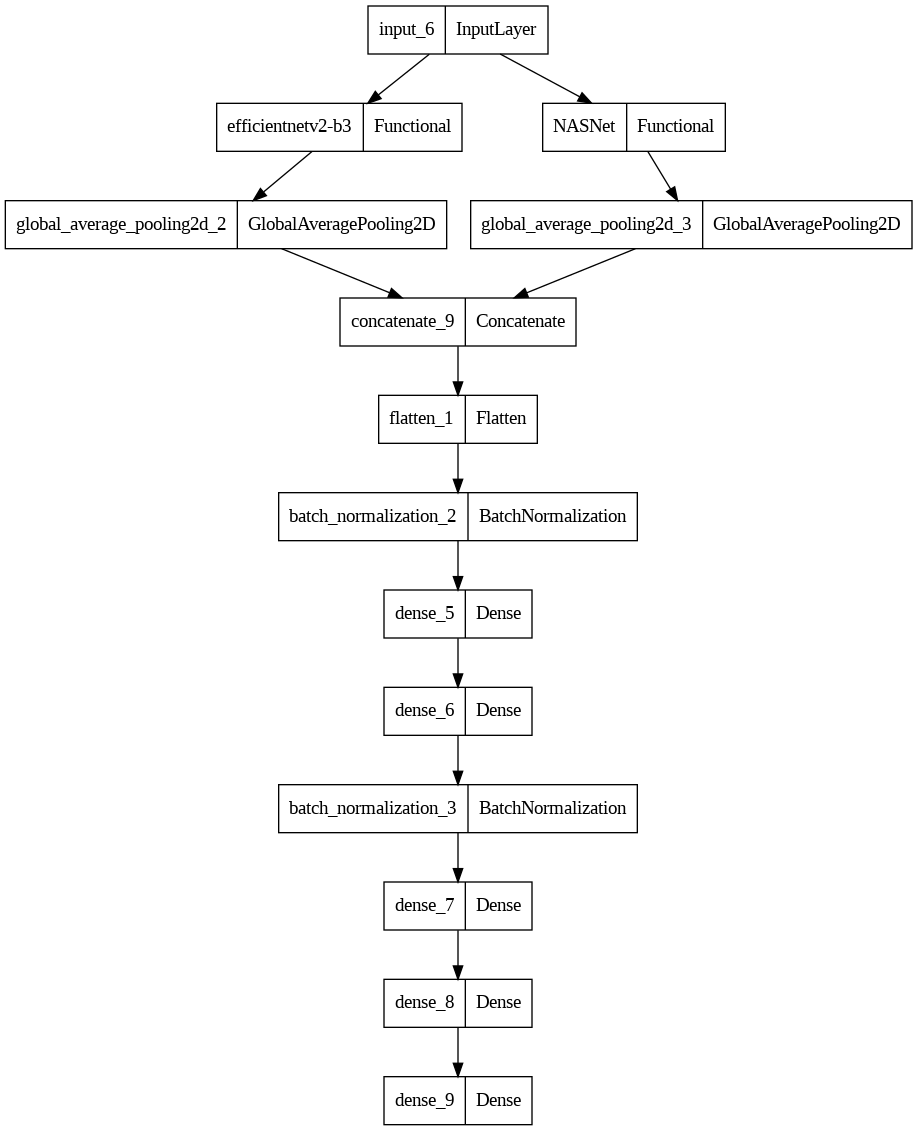

In [27]:
from tensorflow.keras.utils import plot_model
plot_model(model,'model.png')


In [28]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Define a learning rate scheduler
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=2, min_lr=1e-10, verbose=1)

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Fit the model with callbacks
progress = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[lr_scheduler, early_stopping]
)


Epoch 1/25
117/117 [==============================] - 89s 461ms/step - loss: 0.4342 - accuracy: 0.8482 - val_loss: 0.1785 - val_accuracy: 0.9513 - lr: 0.0010
Epoch 2/25
117/117 [==============================] - 42s 357ms/step - loss: 0.1094 - accuracy: 0.9594 - val_loss: 0.0596 - val_accuracy: 0.9825 - lr: 0.0010
Epoch 3/25
117/117 [==============================] - 42s 361ms/step - loss: 0.0744 - accuracy: 0.9746 - val_loss: 0.0368 - val_accuracy: 0.9894 - lr: 0.0010
Epoch 4/25
117/117 [==============================] - 43s 364ms/step - loss: 0.0593 - accuracy: 0.9783 - val_loss: 0.0321 - val_accuracy: 0.9869 - lr: 0.0010
Epoch 5/25
117/117 [==============================] - 43s 365ms/step - loss: 0.0443 - accuracy: 0.9837 - val_loss: 0.0296 - val_accuracy: 0.9900 - lr: 0.0010
Epoch 6/25
117/117 [==============================] - 43s 367ms/step - loss: 0.0432 - accuracy: 0.9831 - val_loss: 0.0271 - val_accuracy: 0.9912 - lr: 0.0010
Epoch 7/25
117/117 [==============================] 

In [29]:
test_loss, test_accuracy = model.evaluate(val_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

25/25 [==============================] - 7s 285ms/step - loss: 0.0180 - accuracy: 0.9937
Test Loss: 0.0180
Test Accuracy: 0.9937


<Figure size 640x480 with 0 Axes>

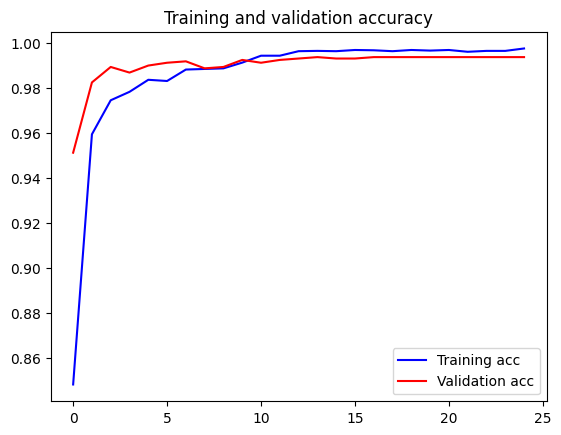

<Figure size 640x480 with 0 Axes>

In [30]:
acc = progress.history['accuracy']
val_acc = progress.history['val_accuracy']
loss = progress.history['loss']
val_loss = progress.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

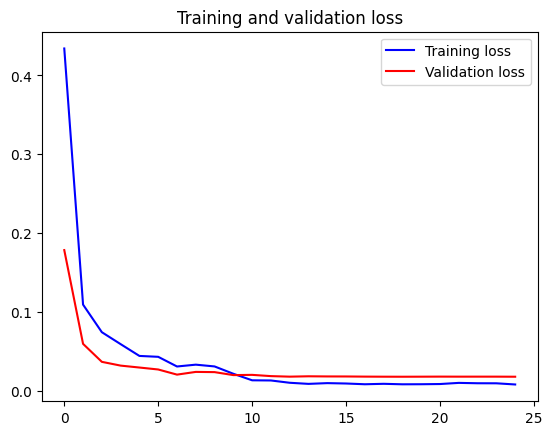

In [31]:
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

26/26 [==============================] - 16s 330ms/step


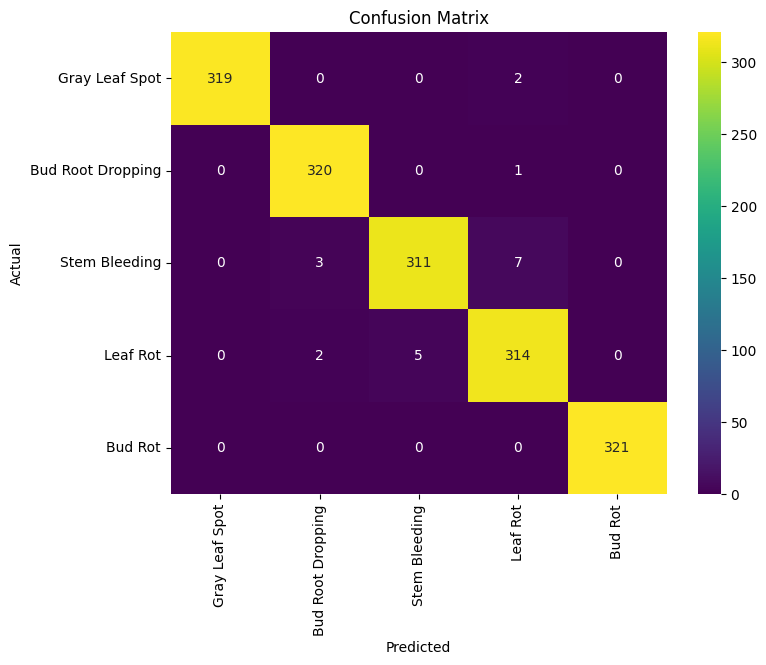

Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming you have already trained and compiled your model
# train_ds is your training dataset

# Make predictions using the trained model
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Get the actual labels from the dataset

# Calculate the confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)
classes = class_folders


import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already trained and compiled your model
# train_ds is your training dataset
classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='viridis',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

cm= confusion_mtx
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]


# Calculate metrics
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)

26/26 [==============================] - 8s 314ms/step


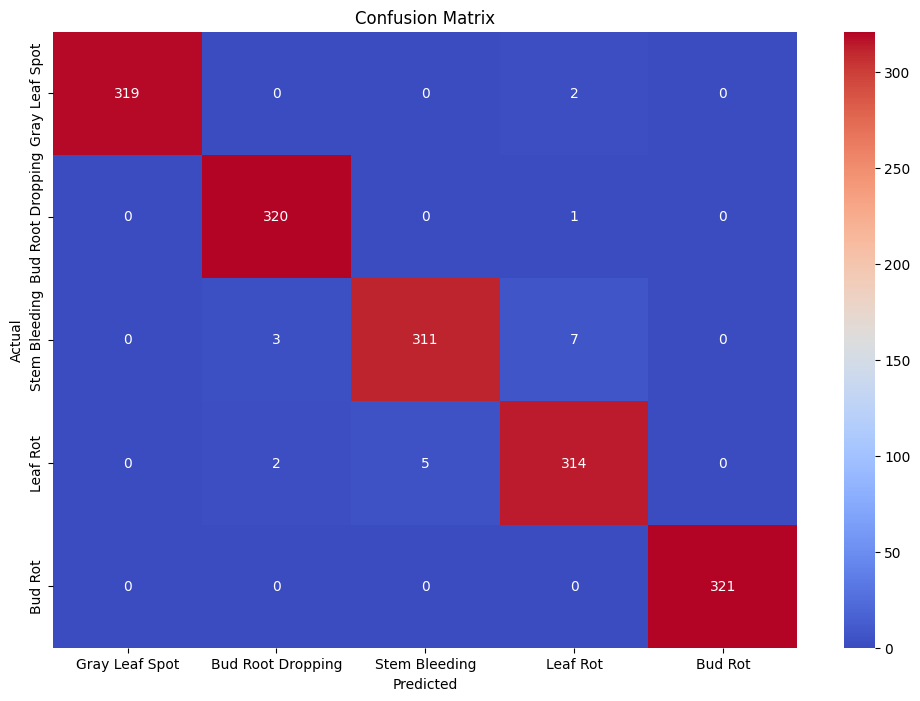

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming you have already trained and compiled your model
# train_ds is your training dataset

# Make predictions using the trained model
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Get the actual labels from the dataset

# Calculate the confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)
classes = class_folders


import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



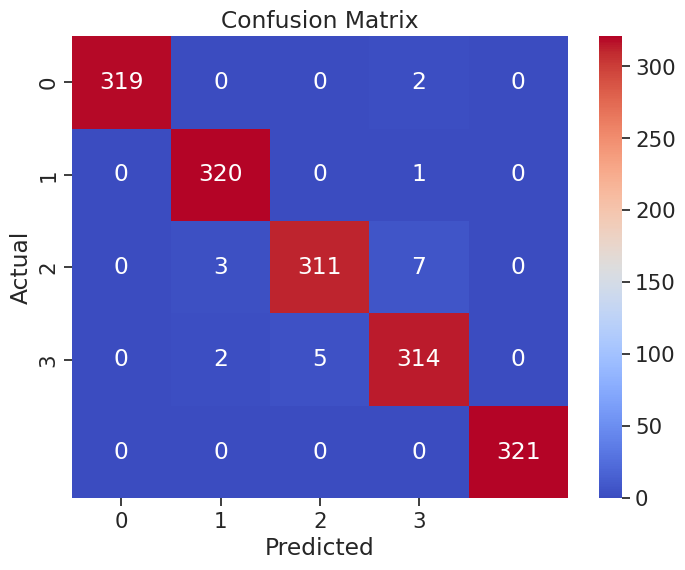

In [34]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already trained and compiled your model
# train_ds is your training dataset
classes = [0,1,2,3]
# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.4)  # Set the font scale
sns.set_style("ticks", {"font.family": "Times New Roman"})  # Set the font family to Times New Roman
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


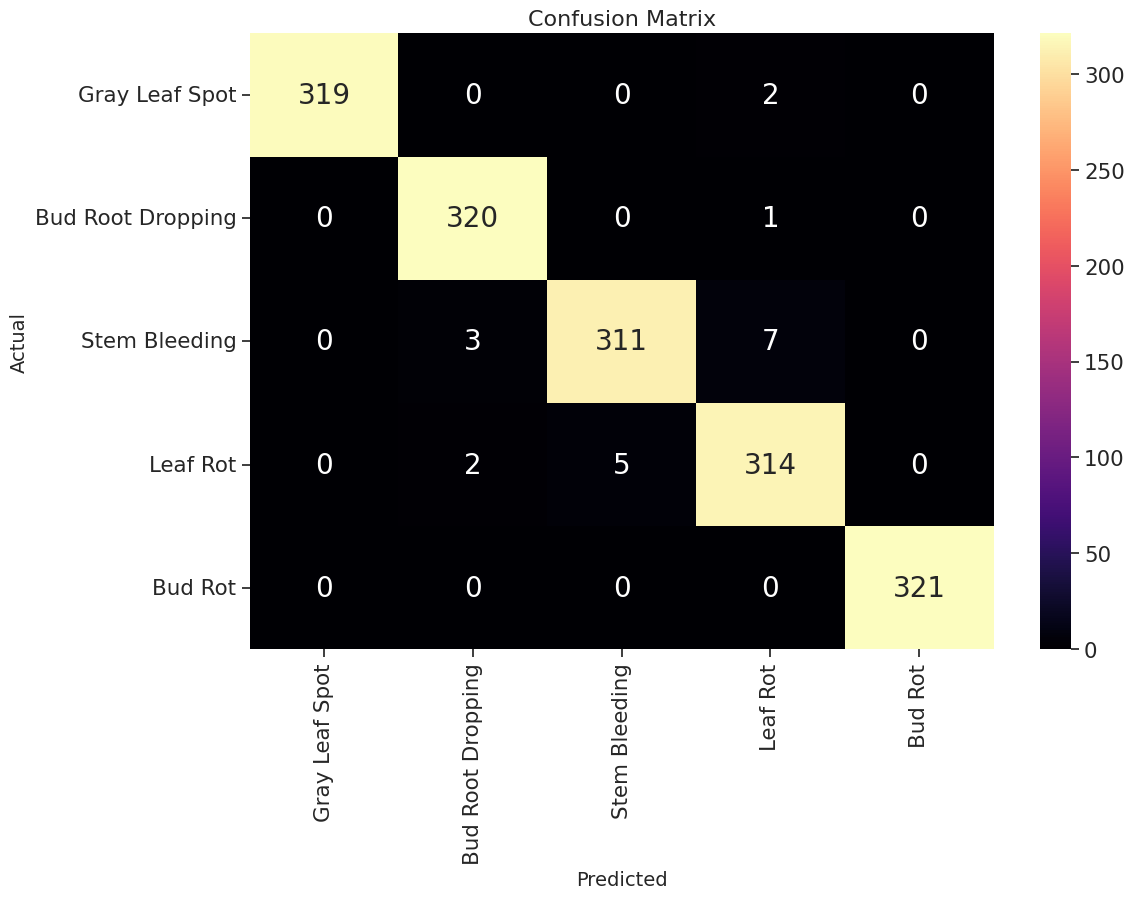

In [35]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='magma',
            xticklabels=classes, yticklabels=classes, annot_kws={"fontsize": 20})  # Adjust fontsize as needed
plt.xlabel('Predicted', fontsize=14)  # Adjust fontsize as needed
plt.ylabel('Actual', fontsize=14)  # Adjust fontsize as needed
plt.title('Confusion Matrix', fontsize=16)  # Adjust fontsize as needed
plt.savefig('images.pdf')
plt.show()


In [36]:
# prompt: print the precision recall and f1 score

from sklearn.metrics import classification_report
# Get the classification report
report = classification_report(test_labels, predicted_labels)

# Print the report
print(report)


              precision    recall  f1-score   support

           0       1.00      0.99      1.00       321
           1       0.98      1.00      0.99       321
           2       0.98      0.97      0.98       321
           3       0.97      0.98      0.97       321
           4       1.00      1.00      1.00       321

    accuracy                           0.99      1605
   macro avg       0.99      0.99      0.99      1605
weighted avg       0.99      0.99      0.99      1605



<Figure size 640x480 with 0 Axes>

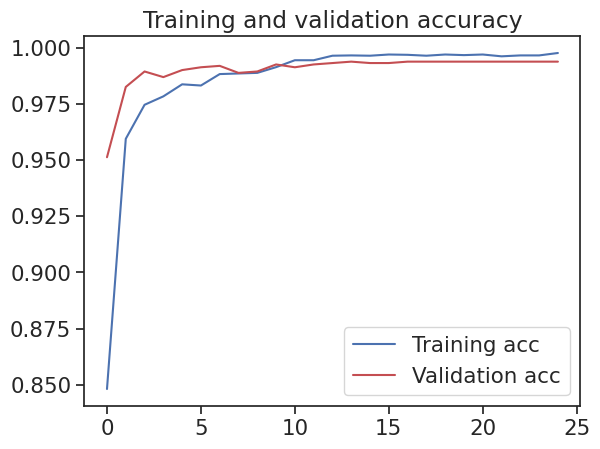

<Figure size 640x480 with 0 Axes>

In [37]:
acc = progress.history['accuracy']
val_acc = progress.history['val_accuracy']
loss = progress.history['loss']
val_loss = progress.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

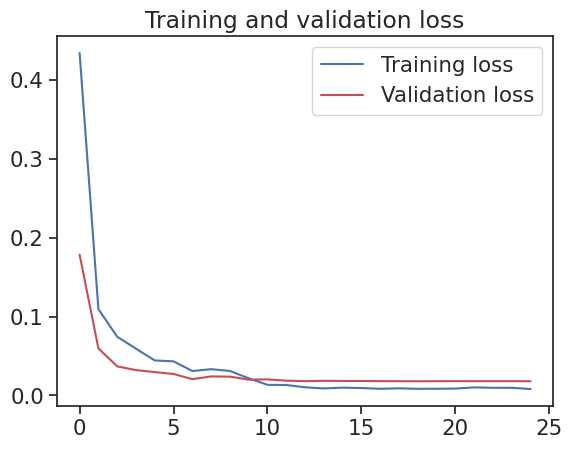

In [38]:
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

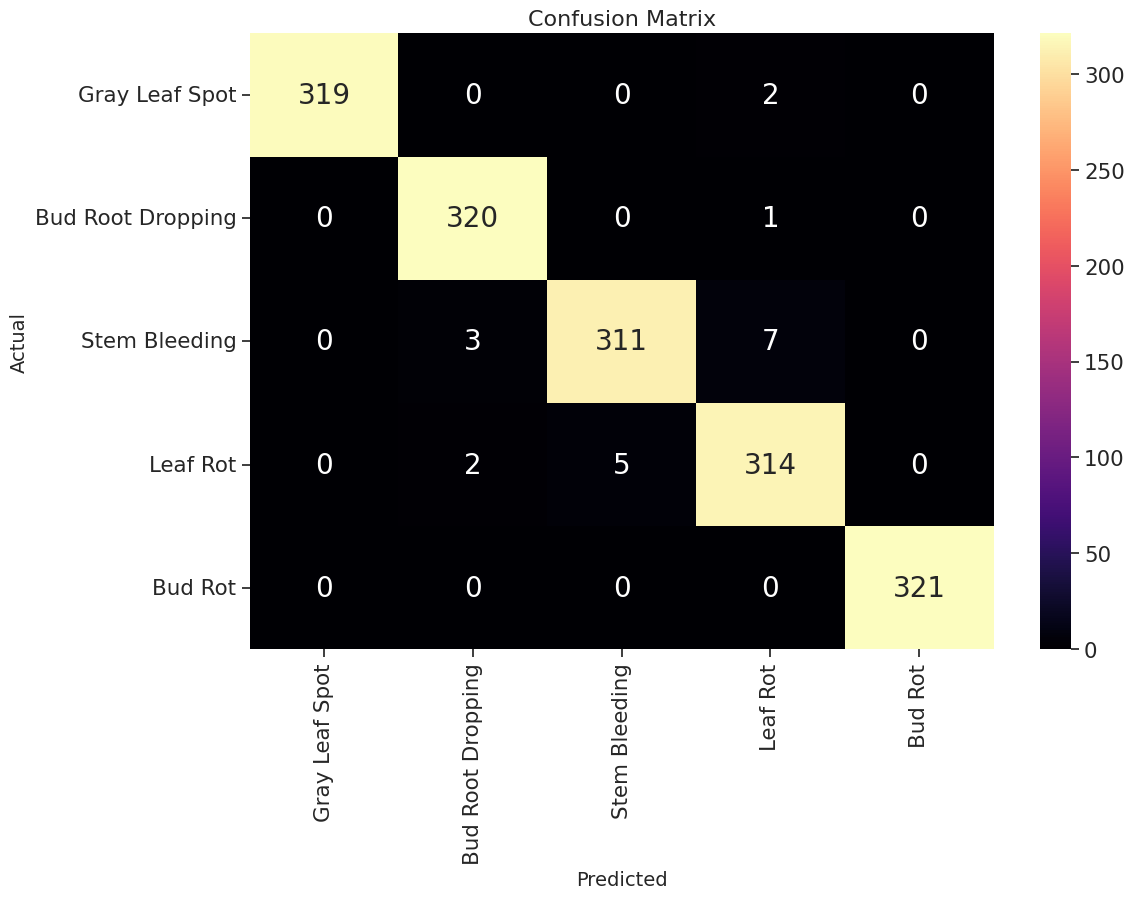

In [39]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='magma',
            xticklabels=classes, yticklabels=classes, annot_kws={"fontsize": 20})  # Adjust fontsize as needed
plt.xlabel('Predicted', fontsize=14)  # Adjust fontsize as needed
plt.ylabel('Actual', fontsize=14)  # Adjust fontsize as needed
plt.title('Confusion Matrix', fontsize=16)  # Adjust fontsize as needed
plt.savefig('images.pdf')
plt.show()


25/25 [==============================] - 7s 267ms/step


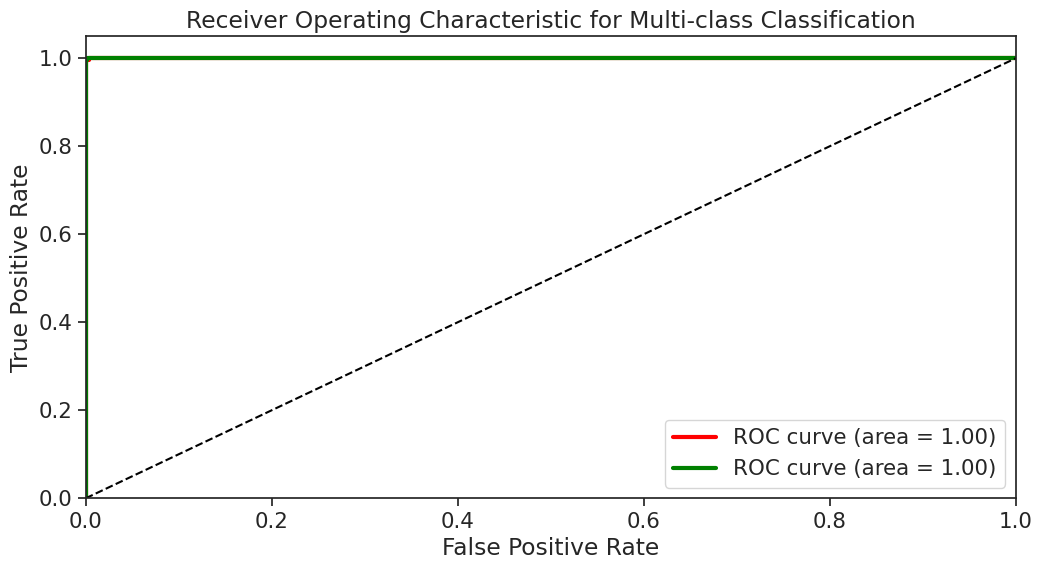

AUC scores:
Class 1: 0.9999853515625
Class 2: 0.9999951171875001


In [40]:
# prompt: ROC Curve display for deep learning

# Get predicted probabilities for each class
predictions = model.predict(val_generator)

# Get the actual labels
test_labels = np.array(val_generator.labels)

# Binarize the test labels
test_labels_bin = keras.utils.to_categorical(test_labels)

# Calculate ROC curves and AUC for each class
fpr = {}
tpr = {}
auc_scores = {}

n_classes = 2  # Adjust this to your number of classes

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], predictions[:, i])
    auc_scores[i] = auc(fpr[i], tpr[i])

# Plot the ROC curves
plt.figure(figsize=(12, 6))


lw = 3
colors = ['red', 'green', 'blue', 'orange']  # Adjust colors for each class

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='ROC curve (area = %0.2f)' % auc_scores[i])

plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Multi-class Classification')
plt.legend(loc="lower right")
plt.show()

# Print AUC scores
print('AUC scores:')
for i, score in auc_scores.items():
    print(f'Class {i+1}: {score}')


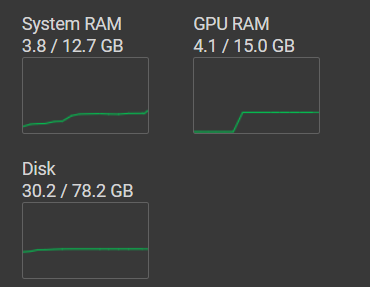

In [41]:
# prompt: print the precision, recall and f1 score

from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already evaluated your model and have the following variables:
# test_generator.classes: True labels
# model.predict(test_generator): Predicted probabilities
# classes: List of class names

# Calculate precision, recall, and F1-score for each class
precision = precision_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))
recall = recall_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))
f1 = f1_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))

# Print the results
for i, cls in enumerate(classes):
    print(f"Class {cls}:")
    print(f"Precision: {precision[i]:.4f}")
    print(f"Recall: {recall[i]:.4f}")
    print(f"F1-score: {f1[i]:.4f}")
    print()


26/26 [==============================] - 7s 271ms/step
Class Gray Leaf Spot:
Precision: 1.0000
Recall: 0.9938
F1-score: 0.9969

Class Bud Root Dropping:
Precision: 0.9846
Recall: 0.9969
F1-score: 0.9907

Class Stem Bleeding:
Precision: 0.9842
Recall: 0.9688
F1-score: 0.9765

Class Leaf Rot:
Precision: 0.9691
Recall: 0.9782
F1-score: 0.9736

Class Bud Rot:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000



In [42]:
# prompt: print the classification report

print(classification_report(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), target_names=classes))


26/26 [==============================] - 7s 265ms/step
                   precision    recall  f1-score   support

   Gray Leaf Spot       1.00      0.99      1.00       321
Bud Root Dropping       0.98      1.00      0.99       321
    Stem Bleeding       0.98      0.97      0.98       321
         Leaf Rot       0.97      0.98      0.97       321
          Bud Rot       1.00      1.00      1.00       321

         accuracy                           0.99      1605
        macro avg       0.99      0.99      0.99      1605
     weighted avg       0.99      0.99      0.99      1605



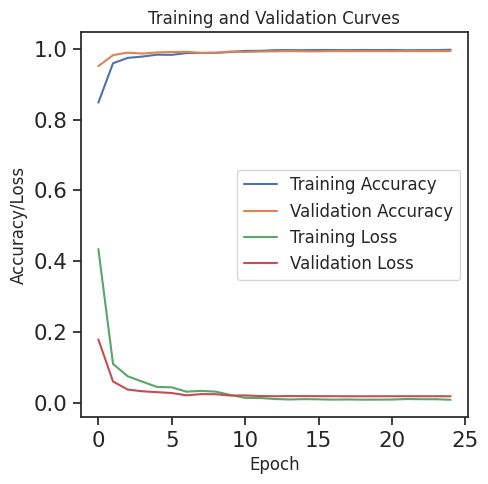

In [43]:
# prompt: plot the trainig and validation curves using seaborn

import matplotlib.pyplot as plt
# Plot training and validation curves using Seaborn
import seaborn as sns

# Create a figure and axes
fig, ax = plt.subplots(figsize=(5, 5))

# Plot training and validation accuracy
sns.lineplot(x=progress.epoch, y=acc, label='Training Accuracy', ax=ax)
sns.lineplot(x=progress.epoch, y=val_acc, label='Validation Accuracy', ax=ax)

# Plot training and validation loss
sns.lineplot(x=progress.epoch, y=loss, label='Training Loss', ax=ax)
sns.lineplot(x=progress.epoch, y=val_loss, label='Validation Loss', ax=ax)

# Set labels and title
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy/Loss', fontsize=12)
ax.set_title('Training and Validation Curves', fontsize=12)

# Add legend
plt.legend(fontsize=12)

# Display the plot
plt.show()


In [ ]:
!pip install LIME

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for LIME: filename=lime-0.2.0.1-py3-none-any.whl size=283835 sha256=6e3ad3da99f5ec6940f11ccccb017d7049037d5777cb8a044f1bfdfe582cbd70
  Stored in directory: /root/.cache/pip/wheels/fd/a2/af/9ac0a1a85a27f314a06b39e1f492bee1547d52549a4606ed89
Successfully built LIME


  0%|          | 0/100 [00:00<?, ?it/s]

1/1 [==============================] - 1s 1s/step


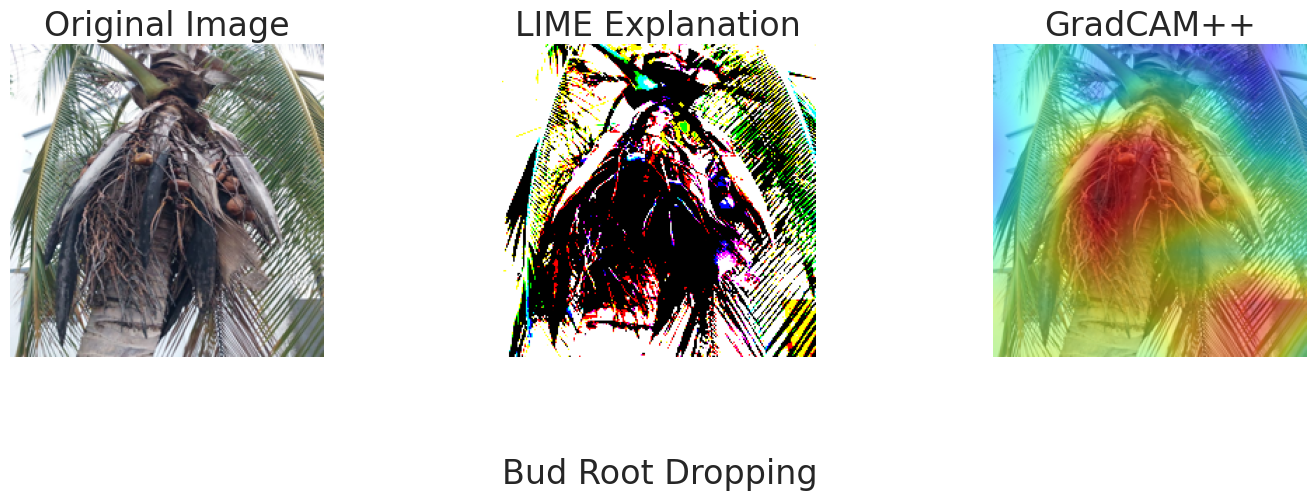

In [ ]:

import numpy as np
from lime import lime_image
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries
from PIL import Image
import cv2
from matplotlib.patches import Rectangle
from skimage.feature import peak_local_max
import tensorflow as tf
import scipy.ndimage

# Load ResNet50 model pre-trained on ImageNet
model = ResNet50(weights='imagenet')

# Function to preprocess input image for ResNet50
def preprocess_image(image_path):
    img = Image.open(image_path)
    img = img.convert('RGB')
    img = img.resize((224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    return x, img

# Grad-CAM++ function
def grad_cam_plus_plus(input_model, image, cls, layer_name):
    last_conv_layer = input_model.get_layer(layer_name)
    conv_output = last_conv_layer.output
    model_with_output = tf.keras.Model(inputs=input_model.inputs, outputs=[conv_output, input_model.output])

    with tf.GradientTape() as tape:
        conv_output, predictions = model_with_output(image)
        output_class = predictions[0, cls]

    grads = tape.gradient(output_class, conv_output)
    first_grads = tf.exp(output_class) * grads
    second_grads = tf.exp(output_class) * grads * grads
    weights = tf.reduce_mean(grads, axis=(0, 1))
    alpha_num = first_grads
    alpha_denom = first_grads * 2.0 + second_grads * conv_output
    alpha_denom = tf.where(alpha_denom != 0.0, alpha_denom, tf.ones_like(alpha_denom) * 1e-10)
    alphas = alpha_num / alpha_denom
    weights_alpha = tf.maximum(weights, 0.0)
    grad_cam = tf.reduce_sum(weights_alpha * conv_output, axis=2)
    grad_cam = tf.maximum(grad_cam, 0)
    heatmap = grad_cam / tf.reduce_max(grad_cam)
    return heatmap.numpy()

# Function to compute the score of the target class
def compute_score(model, img_array, target_class):
    img_array = np.expand_dims(img_array, axis=0)
    predictions = model.predict(img_array)
    return predictions[0][target_class]

# Load and preprocess example image
image_path = '/content/d1/Bud Root Dropping/BudRootDropping002.jpg'
preprocessed_image, original_img = preprocess_image(image_path)

# LIME explanation
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(preprocessed_image[0], model.predict, top_labels=2, hide_color=0, num_samples=100)
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=False, num_features=5, hide_rest=False)

# Grad-CAM++ visualization
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = Image.fromarray(img, 'RGB')
img_resized = img_resized.resize((224, 224))  # ResNet50 input size
img_resized = np.array(img_resized)

img_tensor = np.expand_dims(img_resized, axis=0)
preprocessed_img = preprocess_input(img_tensor)

# Output both predictions (last layer) and last convolutional layer
model_output = model.get_layer('conv5_block3_out').output
model_intermediate = tf.keras.models.Model(inputs=model.input, outputs=(model_output, model.output))

last_conv_output, pred_vec = model_intermediate.predict(preprocessed_img)
last_conv_output = np.squeeze(last_conv_output)

h = int(img_resized.shape[0] / last_conv_output.shape[0])
w = int(img_resized.shape[1] / last_conv_output.shape[1])
upsampled_last_conv_output = scipy.ndimage.zoom(last_conv_output, (h, w, 1), order=1)

last_layer_weights_for_pred = model_intermediate.layers[-1].get_weights()[0][:, np.argmax(pred_vec)]
upsampled_last_conv_output_flat = upsampled_last_conv_output.reshape((-1, 2048))
heat_map = np.dot(upsampled_last_conv_output_flat, last_layer_weights_for_pred)
heat_map = heat_map.reshape((224, 224))

peak_coords = peak_local_max(heat_map, num_peaks=5, threshold_rel=0.5, min_distance=10)

# Overlay the peak coordinates on the original image
plt.figure(figsize=(15, 5))

# Display the original image
plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title("Original Image", fontsize=24)
plt.axis('off')

# Display the LIME explanation
plt.subplot(1, 3, 2)
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
plt.title('LIME Explanation', fontsize=24)
plt.text(0, original_img.size[1] + 90, "Bud Root Dropping", fontsize=24, ha='left')
plt.axis('off')

# Overlay the Grad-CAM++ heatmap on the original image
plt.subplot(1, 3, 3)
plt.imshow(img_resized)
plt.imshow(heat_map, cmap='jet', alpha=0.5)
plt.title('GradCAM++', fontsize=24)
plt.axis('off')

plt.tight_layout()
plt.show()


  0%|          | 0/100 [00:00<?, ?it/s]

1/1 [==============================] - 3s 3s/step


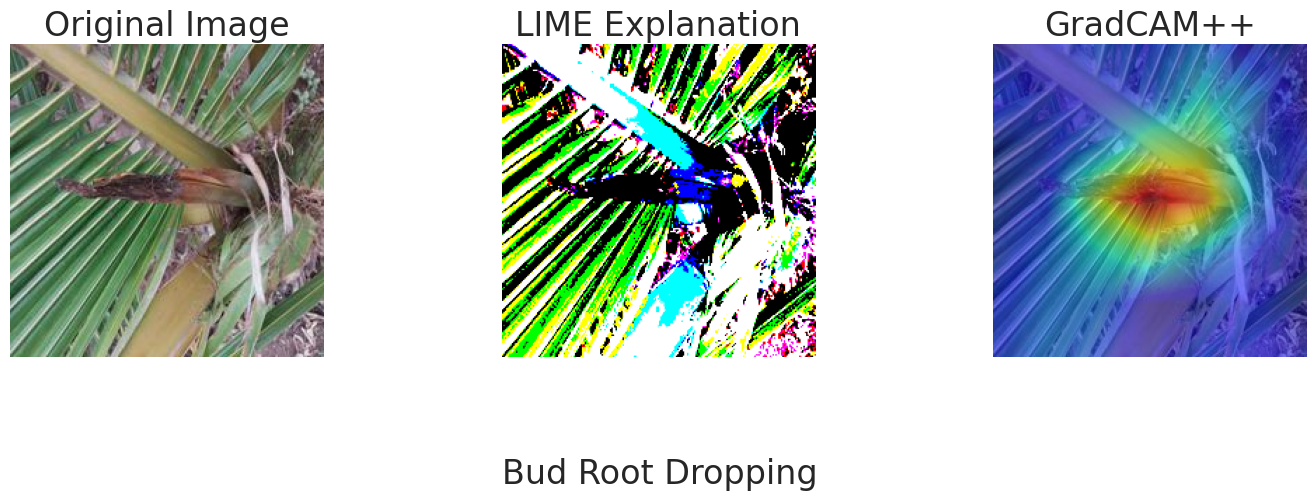

In [ ]:

import numpy as np
from lime import lime_image
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries
from PIL import Image
import cv2
from matplotlib.patches import Rectangle
from skimage.feature import peak_local_max
import tensorflow as tf
import scipy.ndimage

# Load ResNet50 model pre-trained on ImageNet
model = ResNet50(weights='imagenet')

# Function to preprocess input image for ResNet50
def preprocess_image(image_path):
    img = Image.open(image_path)
    img = img.convert('RGB')
    img = img.resize((224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    return x, img

# Grad-CAM++ function
def grad_cam_plus_plus(input_model, image, cls, layer_name):
    last_conv_layer = input_model.get_layer(layer_name)
    conv_output = last_conv_layer.output
    model_with_output = tf.keras.Model(inputs=input_model.inputs, outputs=[conv_output, input_model.output])

    with tf.GradientTape() as tape:
        conv_output, predictions = model_with_output(image)
        output_class = predictions[0, cls]

    grads = tape.gradient(output_class, conv_output)
    first_grads = tf.exp(output_class) * grads
    second_grads = tf.exp(output_class) * grads * grads
    weights = tf.reduce_mean(grads, axis=(0, 1))
    alpha_num = first_grads
    alpha_denom = first_grads * 2.0 + second_grads * conv_output
    alpha_denom = tf.where(alpha_denom != 0.0, alpha_denom, tf.ones_like(alpha_denom) * 1e-10)
    alphas = alpha_num / alpha_denom
    weights_alpha = tf.maximum(weights, 0.0)
    grad_cam = tf.reduce_sum(weights_alpha * conv_output, axis=2)
    grad_cam = tf.maximum(grad_cam, 0)
    heatmap = grad_cam / tf.reduce_max(grad_cam)
    return heatmap.numpy()

# Function to compute the score of the target class
def compute_score(model, img_array, target_class):
    img_array = np.expand_dims(img_array, axis=0)
    predictions = model.predict(img_array)
    return predictions[0][target_class]

# Load and preprocess example image
image_path = '/content/a/Bud Rot/aug_0_BudRot261.jpg'
preprocessed_image, original_img = preprocess_image(image_path)

# LIME explanation
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(preprocessed_image[0], model.predict, top_labels=2, hide_color=0, num_samples=100)
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=False, num_features=5, hide_rest=False)

# Grad-CAM++ visualization
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = Image.fromarray(img, 'RGB')
img_resized = img_resized.resize((224, 224))  # ResNet50 input size
img_resized = np.array(img_resized)

img_tensor = np.expand_dims(img_resized, axis=0)
preprocessed_img = preprocess_input(img_tensor)

# Output both predictions (last layer) and last convolutional layer
model_output = model.get_layer('conv5_block3_out').output
model_intermediate = tf.keras.models.Model(inputs=model.input, outputs=(model_output, model.output))

last_conv_output, pred_vec = model_intermediate.predict(preprocessed_img)
last_conv_output = np.squeeze(last_conv_output)

h = int(img_resized.shape[0] / last_conv_output.shape[0])
w = int(img_resized.shape[1] / last_conv_output.shape[1])
upsampled_last_conv_output = scipy.ndimage.zoom(last_conv_output, (h, w, 1), order=1)

last_layer_weights_for_pred = model_intermediate.layers[-1].get_weights()[0][:, np.argmax(pred_vec)]
upsampled_last_conv_output_flat = upsampled_last_conv_output.reshape((-1, 2048))
heat_map = np.dot(upsampled_last_conv_output_flat, last_layer_weights_for_pred)
heat_map = heat_map.reshape((224, 224))

peak_coords = peak_local_max(heat_map, num_peaks=5, threshold_rel=0.5, min_distance=10)

# Overlay the peak coordinates on the original image
plt.figure(figsize=(15, 5))

# Display the original image
plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title("Original Image", fontsize=24)
plt.axis('off')

# Display the LIME explanation
plt.subplot(1, 3, 2)
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
plt.title('LIME Explanation', fontsize=24)
plt.text(0, original_img.size[1] + 90, "Bud Root", fontsize=24, ha='left')
plt.axis('off')

# Overlay the Grad-CAM++ heatmap on the original image
plt.subplot(1, 3, 3)
plt.imshow(img_resized)
plt.imshow(heat_map, cmap='jet', alpha=0.5)
plt.title('GradCAM++', fontsize=24)
plt.axis('off')

plt.tight_layout()
plt.show()


  0%|          | 0/100 [00:00<?, ?it/s]

1/1 [==============================] - 1s 944ms/step


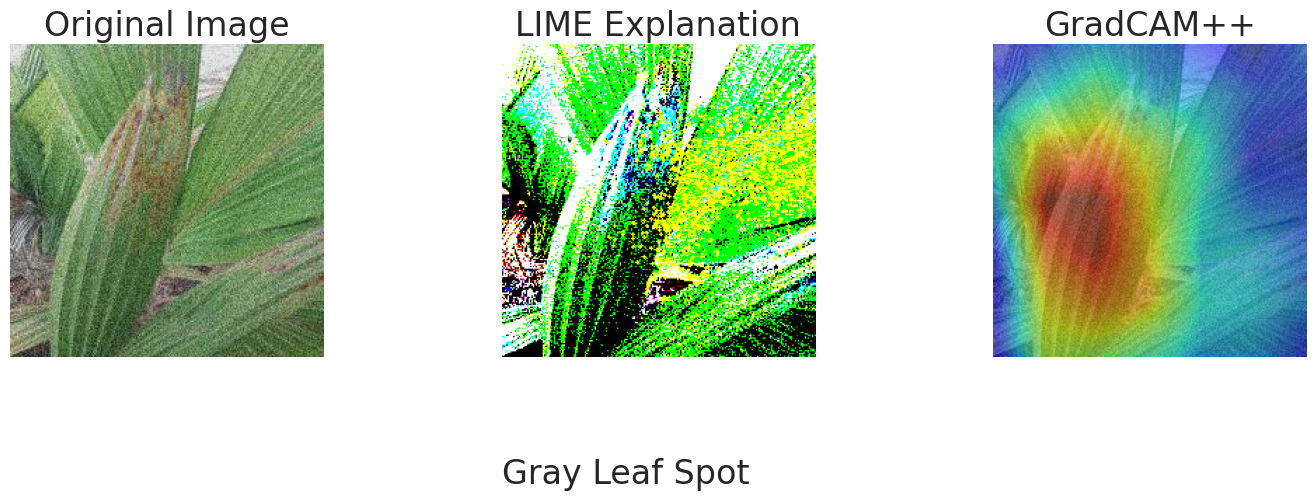

In [ ]:

import numpy as np
from lime import lime_image
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries
from PIL import Image
import cv2
from matplotlib.patches import Rectangle
from skimage.feature import peak_local_max
import tensorflow as tf
import scipy.ndimage

# Load ResNet50 model pre-trained on ImageNet
model = ResNet50(weights='imagenet')

# Function to preprocess input image for ResNet50
def preprocess_image(image_path):
    img = Image.open(image_path)
    img = img.convert('RGB')
    img = img.resize((224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    return x, img

# Grad-CAM++ function
def grad_cam_plus_plus(input_model, image, cls, layer_name):
    last_conv_layer = input_model.get_layer(layer_name)
    conv_output = last_conv_layer.output
    model_with_output = tf.keras.Model(inputs=input_model.inputs, outputs=[conv_output, input_model.output])

    with tf.GradientTape() as tape:
        conv_output, predictions = model_with_output(image)
        output_class = predictions[0, cls]

    grads = tape.gradient(output_class, conv_output)
    first_grads = tf.exp(output_class) * grads
    second_grads = tf.exp(output_class) * grads * grads
    weights = tf.reduce_mean(grads, axis=(0, 1))
    alpha_num = first_grads
    alpha_denom = first_grads * 2.0 + second_grads * conv_output
    alpha_denom = tf.where(alpha_denom != 0.0, alpha_denom, tf.ones_like(alpha_denom) * 1e-10)
    alphas = alpha_num / alpha_denom
    weights_alpha = tf.maximum(weights, 0.0)
    grad_cam = tf.reduce_sum(weights_alpha * conv_output, axis=2)
    grad_cam = tf.maximum(grad_cam, 0)
    heatmap = grad_cam / tf.reduce_max(grad_cam)
    return heatmap.numpy()

# Function to compute the score of the target class
def compute_score(model, img_array, target_class):
    img_array = np.expand_dims(img_array, axis=0)
    predictions = model.predict(img_array)
    return predictions[0][target_class]

# Load and preprocess example image
image_path = '/content/a/Gray Leaf Spot/aug_0_GrayLeafSpot1647.jpg'
preprocessed_image, original_img = preprocess_image(image_path)

# LIME explanation
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(preprocessed_image[0], model.predict, top_labels=2, hide_color=0, num_samples=100)
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=False, num_features=5, hide_rest=False)

# Grad-CAM++ visualization
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = Image.fromarray(img, 'RGB')
img_resized = img_resized.resize((224, 224))  # ResNet50 input size
img_resized = np.array(img_resized)

img_tensor = np.expand_dims(img_resized, axis=0)
preprocessed_img = preprocess_input(img_tensor)

# Output both predictions (last layer) and last convolutional layer
model_output = model.get_layer('conv5_block3_out').output
model_intermediate = tf.keras.models.Model(inputs=model.input, outputs=(model_output, model.output))

last_conv_output, pred_vec = model_intermediate.predict(preprocessed_img)
last_conv_output = np.squeeze(last_conv_output)

h = int(img_resized.shape[0] / last_conv_output.shape[0])
w = int(img_resized.shape[1] / last_conv_output.shape[1])
upsampled_last_conv_output = scipy.ndimage.zoom(last_conv_output, (h, w, 1), order=1)

last_layer_weights_for_pred = model_intermediate.layers[-1].get_weights()[0][:, np.argmax(pred_vec)]
upsampled_last_conv_output_flat = upsampled_last_conv_output.reshape((-1, 2048))
heat_map = np.dot(upsampled_last_conv_output_flat, last_layer_weights_for_pred)
heat_map = heat_map.reshape((224, 224))

peak_coords = peak_local_max(heat_map, num_peaks=5, threshold_rel=0.5, min_distance=10)

# Overlay the peak coordinates on the original image
plt.figure(figsize=(15, 5))

# Display the original image
plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title("Original Image", fontsize=24)
plt.axis('off')

# Display the LIME explanation
plt.subplot(1, 3, 2)
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
plt.title('LIME Explanation', fontsize=24)
plt.text(0, original_img.size[1] + 90, "Gray Leaf Spot", fontsize=24, ha='left')
plt.axis('off')

# Overlay the Grad-CAM++ heatmap on the original image
plt.subplot(1, 3, 3)
plt.imshow(img_resized)
plt.imshow(heat_map, cmap='jet', alpha=0.5)
plt.title('GradCAM++', fontsize=24)
plt.axis('off')

plt.tight_layout()
plt.show()


  0%|          | 0/100 [00:00<?, ?it/s]

1/1 [==============================] - 1s 866ms/step


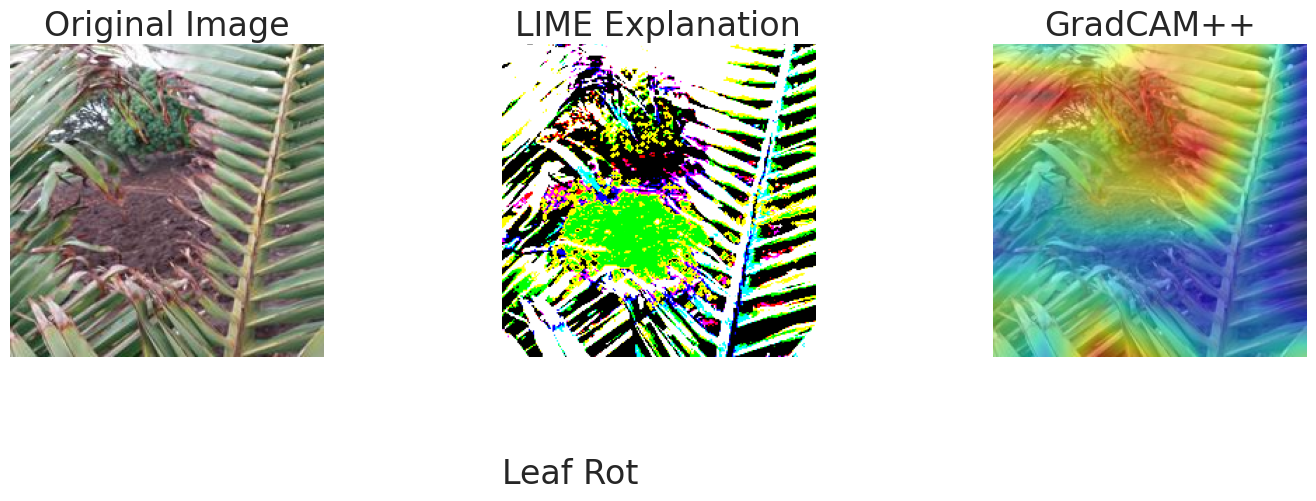

In [ ]:

import numpy as np
from lime import lime_image
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries
from PIL import Image
import cv2
from matplotlib.patches import Rectangle
from skimage.feature import peak_local_max
import tensorflow as tf
import scipy.ndimage

# Load ResNet50 model pre-trained on ImageNet
model = ResNet50(weights='imagenet')

# Function to preprocess input image for ResNet50
def preprocess_image(image_path):
    img = Image.open(image_path)
    img = img.convert('RGB')
    img = img.resize((224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    return x, img

# Grad-CAM++ function
def grad_cam_plus_plus(input_model, image, cls, layer_name):
    last_conv_layer = input_model.get_layer(layer_name)
    conv_output = last_conv_layer.output
    model_with_output = tf.keras.Model(inputs=input_model.inputs, outputs=[conv_output, input_model.output])

    with tf.GradientTape() as tape:
        conv_output, predictions = model_with_output(image)
        output_class = predictions[0, cls]

    grads = tape.gradient(output_class, conv_output)
    first_grads = tf.exp(output_class) * grads
    second_grads = tf.exp(output_class) * grads * grads
    weights = tf.reduce_mean(grads, axis=(0, 1))
    alpha_num = first_grads
    alpha_denom = first_grads * 2.0 + second_grads * conv_output
    alpha_denom = tf.where(alpha_denom != 0.0, alpha_denom, tf.ones_like(alpha_denom) * 1e-10)
    alphas = alpha_num / alpha_denom
    weights_alpha = tf.maximum(weights, 0.0)
    grad_cam = tf.reduce_sum(weights_alpha * conv_output, axis=2)
    grad_cam = tf.maximum(grad_cam, 0)
    heatmap = grad_cam / tf.reduce_max(grad_cam)
    return heatmap.numpy()

# Function to compute the score of the target class
def compute_score(model, img_array, target_class):
    img_array = np.expand_dims(img_array, axis=0)
    predictions = model.predict(img_array)
    return predictions[0][target_class]

# Load and preprocess example image
image_path = '/content/a/Leaf Rot/aug_0_LeafRot307.jpg'
preprocessed_image, original_img = preprocess_image(image_path)

# LIME explanation
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(preprocessed_image[0], model.predict, top_labels=2, hide_color=0, num_samples=100)
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=False, num_features=5, hide_rest=False)

# Grad-CAM++ visualization
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = Image.fromarray(img, 'RGB')
img_resized = img_resized.resize((224, 224))  # ResNet50 input size
img_resized = np.array(img_resized)

img_tensor = np.expand_dims(img_resized, axis=0)
preprocessed_img = preprocess_input(img_tensor)

# Output both predictions (last layer) and last convolutional layer
model_output = model.get_layer('conv5_block3_out').output
model_intermediate = tf.keras.models.Model(inputs=model.input, outputs=(model_output, model.output))

last_conv_output, pred_vec = model_intermediate.predict(preprocessed_img)
last_conv_output = np.squeeze(last_conv_output)

h = int(img_resized.shape[0] / last_conv_output.shape[0])
w = int(img_resized.shape[1] / last_conv_output.shape[1])
upsampled_last_conv_output = scipy.ndimage.zoom(last_conv_output, (h, w, 1), order=1)

last_layer_weights_for_pred = model_intermediate.layers[-1].get_weights()[0][:, np.argmax(pred_vec)]
upsampled_last_conv_output_flat = upsampled_last_conv_output.reshape((-1, 2048))
heat_map = np.dot(upsampled_last_conv_output_flat, last_layer_weights_for_pred)
heat_map = heat_map.reshape((224, 224))

peak_coords = peak_local_max(heat_map, num_peaks=5, threshold_rel=0.5, min_distance=10)

# Overlay the peak coordinates on the original image
plt.figure(figsize=(15, 5))

# Display the original image
plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title("Original Image", fontsize=24)
plt.axis('off')

# Display the LIME explanation
plt.subplot(1, 3, 2)
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
plt.title('LIME Explanation', fontsize=24)
plt.text(0, original_img.size[1] + 90, "Leaf Rot", fontsize=24, ha='left')
plt.axis('off')

# Overlay the Grad-CAM++ heatmap on the original image
plt.subplot(1, 3, 3)
plt.imshow(img_resized)
plt.imshow(heat_map, cmap='jet', alpha=0.5)
plt.title('GradCAM++', fontsize=24)
plt.axis('off')

plt.tight_layout()
plt.show()


  0%|          | 0/100 [00:00<?, ?it/s]

1/1 [==============================] - 1s 1s/step


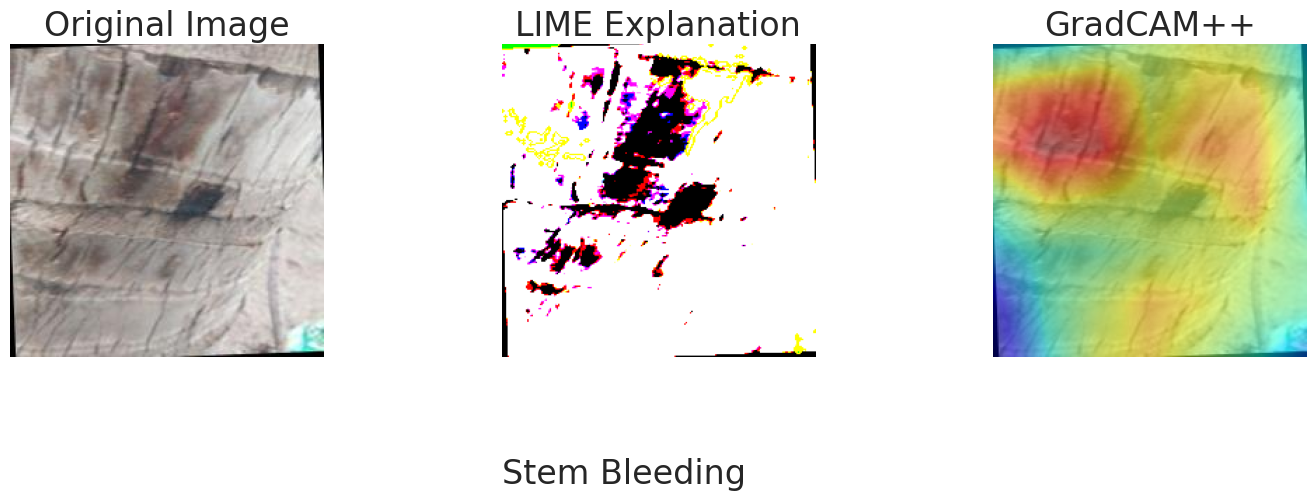

In [ ]:

import numpy as np
from lime import lime_image
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries
from PIL import Image
import cv2
from matplotlib.patches import Rectangle
from skimage.feature import peak_local_max
import tensorflow as tf
import scipy.ndimage

# Load ResNet50 model pre-trained on ImageNet
model = ResNet50(weights='imagenet')

# Function to preprocess input image for ResNet50
def preprocess_image(image_path):
    img = Image.open(image_path)
    img = img.convert('RGB')
    img = img.resize((224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    return x, img

# Grad-CAM++ function
def grad_cam_plus_plus(input_model, image, cls, layer_name):
    last_conv_layer = input_model.get_layer(layer_name)
    conv_output = last_conv_layer.output
    model_with_output = tf.keras.Model(inputs=input_model.inputs, outputs=[conv_output, input_model.output])

    with tf.GradientTape() as tape:
        conv_output, predictions = model_with_output(image)
        output_class = predictions[0, cls]

    grads = tape.gradient(output_class, conv_output)
    first_grads = tf.exp(output_class) * grads
    second_grads = tf.exp(output_class) * grads * grads
    weights = tf.reduce_mean(grads, axis=(0, 1))
    alpha_num = first_grads
    alpha_denom = first_grads * 2.0 + second_grads * conv_output
    alpha_denom = tf.where(alpha_denom != 0.0, alpha_denom, tf.ones_like(alpha_denom) * 1e-10)
    alphas = alpha_num / alpha_denom
    weights_alpha = tf.maximum(weights, 0.0)
    grad_cam = tf.reduce_sum(weights_alpha * conv_output, axis=2)
    grad_cam = tf.maximum(grad_cam, 0)
    heatmap = grad_cam / tf.reduce_max(grad_cam)
    return heatmap.numpy()

# Function to compute the score of the target class
def compute_score(model, img_array, target_class):
    img_array = np.expand_dims(img_array, axis=0)
    predictions = model.predict(img_array)
    return predictions[0][target_class]

# Load and preprocess example image
image_path = '/content/a/Stem Bleeding/aug_0_StemBleeding593.jpg'
preprocessed_image, original_img = preprocess_image(image_path)

# LIME explanation
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(preprocessed_image[0], model.predict, top_labels=2, hide_color=0, num_samples=100)
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=False, num_features=5, hide_rest=False)

# Grad-CAM++ visualization
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = Image.fromarray(img, 'RGB')
img_resized = img_resized.resize((224, 224))  # ResNet50 input size
img_resized = np.array(img_resized)

img_tensor = np.expand_dims(img_resized, axis=0)
preprocessed_img = preprocess_input(img_tensor)

# Output both predictions (last layer) and last convolutional layer
model_output = model.get_layer('conv5_block3_out').output
model_intermediate = tf.keras.models.Model(inputs=model.input, outputs=(model_output, model.output))

last_conv_output, pred_vec = model_intermediate.predict(preprocessed_img)
last_conv_output = np.squeeze(last_conv_output)

h = int(img_resized.shape[0] / last_conv_output.shape[0])
w = int(img_resized.shape[1] / last_conv_output.shape[1])
upsampled_last_conv_output = scipy.ndimage.zoom(last_conv_output, (h, w, 1), order=1)

last_layer_weights_for_pred = model_intermediate.layers[-1].get_weights()[0][:, np.argmax(pred_vec)]
upsampled_last_conv_output_flat = upsampled_last_conv_output.reshape((-1, 2048))
heat_map = np.dot(upsampled_last_conv_output_flat, last_layer_weights_for_pred)
heat_map = heat_map.reshape((224, 224))

peak_coords = peak_local_max(heat_map, num_peaks=5, threshold_rel=0.5, min_distance=10)

# Overlay the peak coordinates on the original image
plt.figure(figsize=(15, 5))

# Display the original image
plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title("Original Image", fontsize=24)
plt.axis('off')

# Display the LIME explanation
plt.subplot(1, 3, 2)
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
plt.title('LIME Explanation', fontsize=24)
plt.text(0, original_img.size[1] + 90, "Stem Bleeding", fontsize=24, ha='left')
plt.axis('off')

# Overlay the Grad-CAM++ heatmap on the original image
plt.subplot(1, 3, 3)
plt.imshow(img_resized)
plt.imshow(heat_map, cmap='jet', alpha=0.5)
plt.title('GradCAM++', fontsize=24)
plt.axis('off')

plt.tight_layout()
plt.show()
